In [23]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [26]:
# Load Data

df = pd.read_csv("../data/bread basket.csv")
df.columns = df.columns.str.strip()
df.head(10)

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend
5,3,Cookies,30-10-2016 10:07,morning,weekend
6,4,Muffin,30-10-2016 10:08,morning,weekend
7,5,Coffee,30-10-2016 10:13,morning,weekend
8,5,Pastry,30-10-2016 10:13,morning,weekend
9,5,Bread,30-10-2016 10:13,morning,weekend


In [27]:
df.isnull().sum()

Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64

In [28]:
if 'Item' in df.columns:
    df = df[df['Item'] != 'NONE']
df.head(10)

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend
5,3,Cookies,30-10-2016 10:07,morning,weekend
6,4,Muffin,30-10-2016 10:08,morning,weekend
7,5,Coffee,30-10-2016 10:13,morning,weekend
8,5,Pastry,30-10-2016 10:13,morning,weekend
9,5,Bread,30-10-2016 10:13,morning,weekend


In [17]:
# EDA (Exploratory Data Analysis)

sns.set_theme(style="whitegrid")

C:\Users\leona\AppData\Local\Temp\ipykernel_19424\858107045.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, palette='viridis')


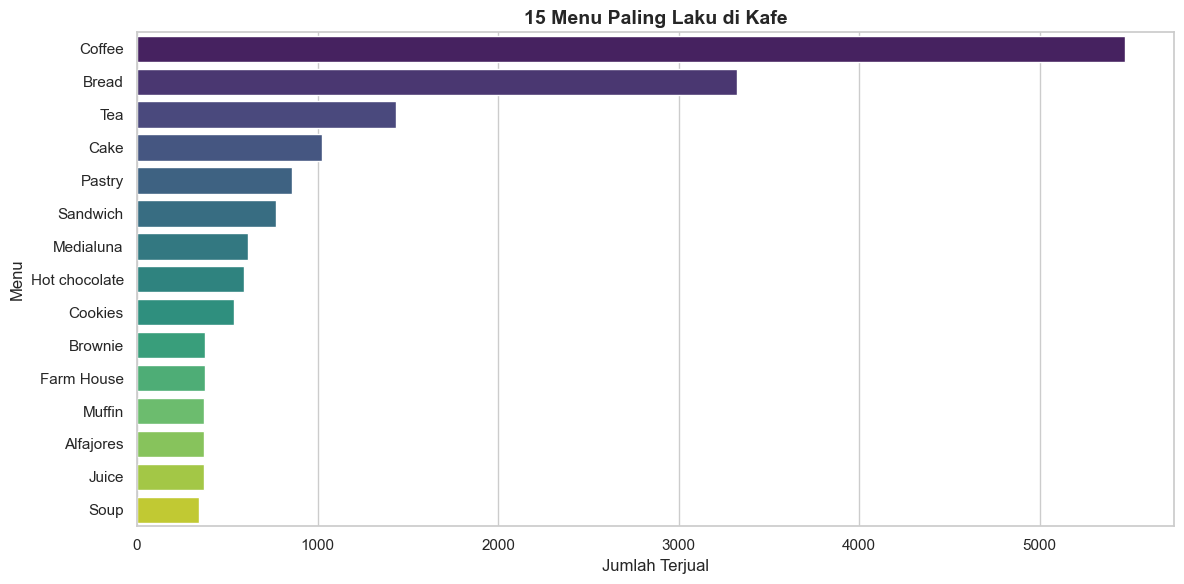

In [29]:
# 1. 15 Menu Paling Laku
plt.figure(figsize=(12, 6))
top_items = df['Item'].value_counts().head(15)
sns.barplot(x=top_items.values, y=top_items.index, palette='viridis')
plt.title('15 Menu Paling Laku di Kafe', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Terjual')
plt.ylabel('Menu')
plt.tight_layout()
plt.show()

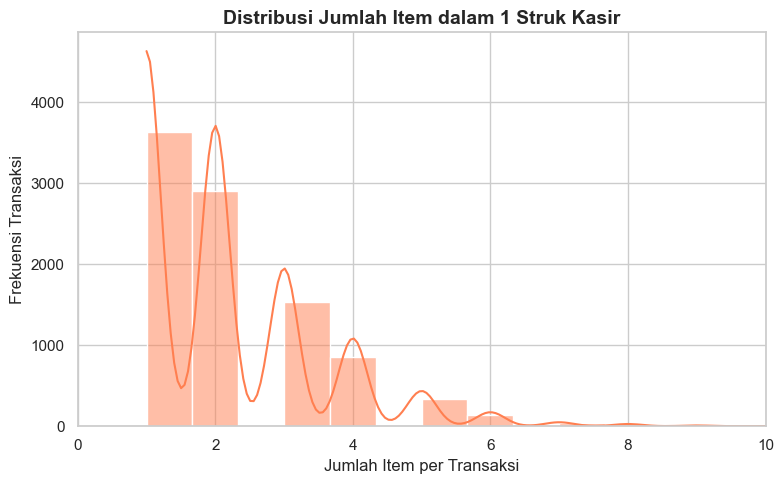

In [30]:
# 2. Distribusi Jumlah Item per Transaksi
plt.figure(figsize=(8, 5))
items_per_transaction = df.groupby('Transaction')['Item'].count()
# Kita batasi sumbu x sampai 10 agar grafiknya tidak rusak karena outlier (orang yang beli terlalu banyak)
sns.histplot(items_per_transaction, bins=15, kde=True, color='coral')
plt.title('Distribusi Jumlah Item dalam 1 Struk Kasir', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Item per Transaksi')
plt.ylabel('Frekuensi Transaksi')
plt.xlim(0, 10) 
plt.tight_layout()
plt.show()

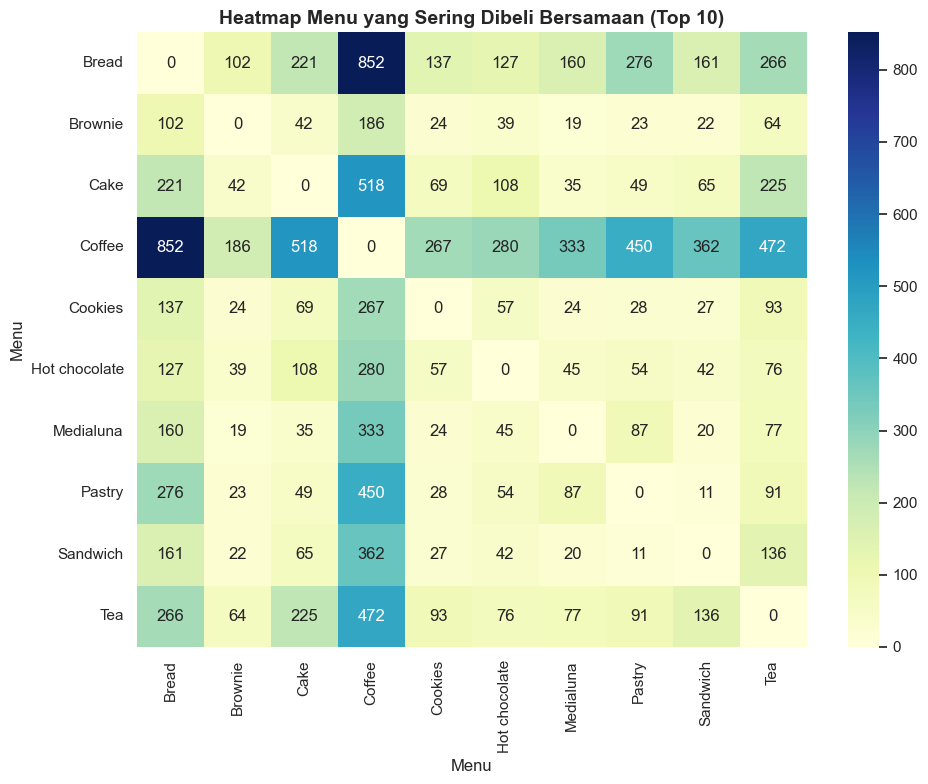

In [ ]:
# 3. Heatmap Co-Occurence
top_10_items = df['Item'].value_counts().head(10).index
df_top = df[df['Item'].isin(top_10_items)]

plt.figure(figsize=(10, 8))
# Membangun matriks berdasarkan Transaction (Struk Kasir), BUKAN CustomerName lagi
item_transaction_matrix = pd.crosstab(df_top['Item'], df_top['Transaction']).clip(upper=1)
co_occurrence = item_transaction_matrix.dot(item_transaction_matrix.T)
np.fill_diagonal(co_occurrence.values, 0)

sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Heatmap Menu yang Sering Dibeli Bersamaan (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Menu')
plt.ylabel('Menu')
plt.tight_layout()
plt.show()